## SPACESHIP TITANIC

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension! 

Use ML to predict which passengers abord the spaceship were transported to the alternate dimension.

In [1701]:
import opendatasets as od
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif,RFECV,mutual_info_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import make_column_selector,make_column_transformer,ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import tensorflow as tf
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_auc_score,roc_curve
from category_encoders import MEstimateEncoder
from sklearn.decomposition import PCA
from lightgbm import LGBMClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint,uniform
from sklearn.utils import shuffle
from sklearn.model_selection import learning_curve
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier,VotingClassifier,StackingClassifier

In [1702]:
od.download_kaggle_dataset("https://www.kaggle.com/competitions/spaceship-titanic",data_dir="./datasets")

Skipping, found downloaded files in "./datasets/spaceship-titanic" (use force=True to force download)


In [1703]:
spaceship_train_df = pd.read_csv("./datasets/spaceship-titanic/train.csv")
spaceship_test_df = pd.read_csv("./datasets/spaceship-titanic/test.csv")

In [1704]:
spaceship_train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### EDA AND FEATURE CREATION
**EDA** is vital to understanding how predictors look like, what information they convey and are they related to the target if at all etc.

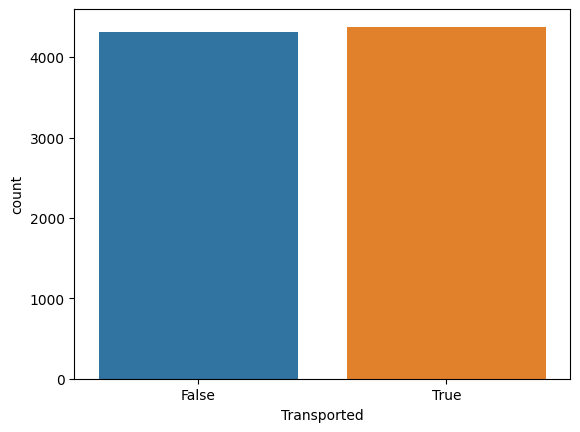

In [1705]:
# check class proportions
sns.countplot(x=spaceship_train_df['Transported'])
plt.show()

In [1706]:
y_train = spaceship_train_df.pop('Transported')

In [1707]:
X_test = spaceship_test_df.copy()
X_train = spaceship_train_df.copy()

In [1708]:
X_train = X_train.join(y_train)

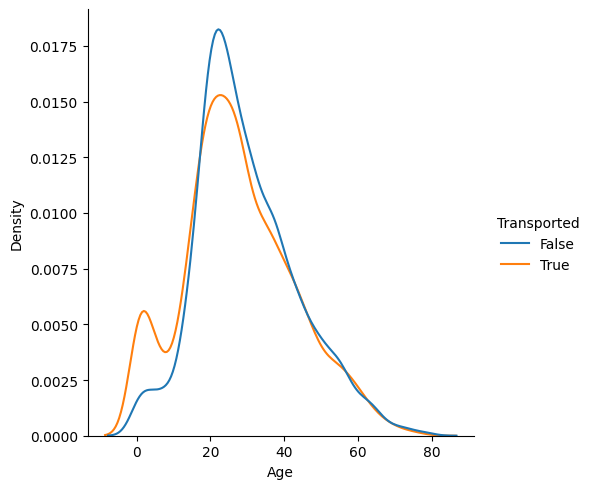

In [1709]:
# plot frequency distribution of passengers by age transported 
sns.displot(data=X_train,x="Age",hue="Transported",kind='kde')
plt.show()

Observation:
1. Most passengers transported were between age group of 20-40 yrs.
2. More Passengers in the age group 0-18 yrs were transported than those who were not.
3. Most of the passengers aboard the ship were between 18-50 yrs of age.

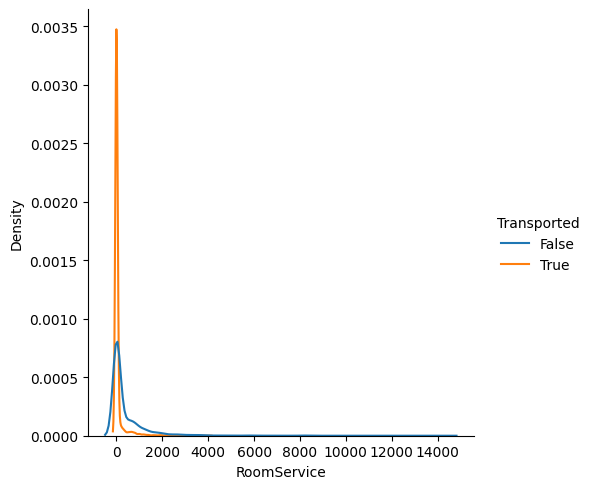

In [1710]:
sns.displot(data=X_train,x="RoomService",hue="Transported",kind='kde')
plt.show()

In [1711]:
X_train.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [1712]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


**Passenger ID** has groupID & passenger number. Since passengers with similar groupID are often family members we extract the information.

In [1713]:
X_train['GroupID'] = X_train['PassengerId'].str.split('_',expand=True)[0].astype(int)
X_train['PassengerNum'] = X_train['PassengerId'].str.split('_',expand=True)[1].astype(int)

In [1714]:
X_test['GroupID'] = X_test['PassengerId'].str.split('_',expand=True)[0].astype(int)
X_test['PassengerNum'] = X_test['PassengerId'].str.split('_',expand=True)[1].astype(int)

In [1715]:
res = X_train.groupby(['GroupID'])['Transported'].agg(['mean'])

In [1716]:
res.head()

,mean
GroupID,
1,0.0
2,1.0
3,0.0
4,1.0
5,1.0


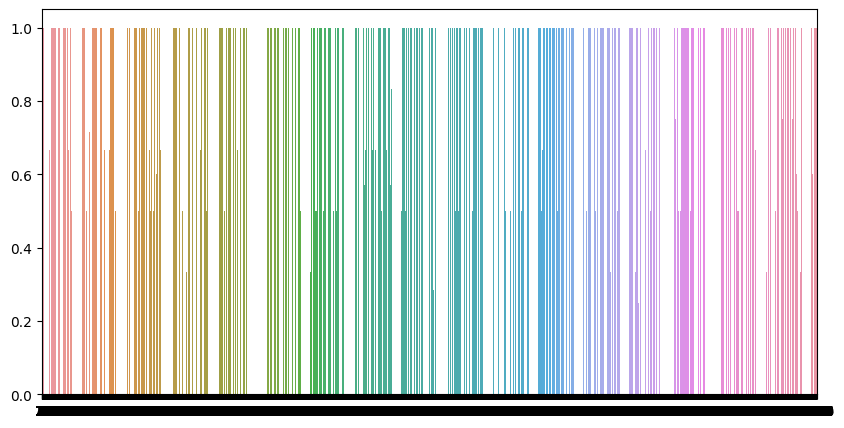

In [1717]:
x = list(res.index)
y = list(res['mean'])
plt.figure(figsize=(10,5))
sns.barplot(x=x,y=y)
plt.show()

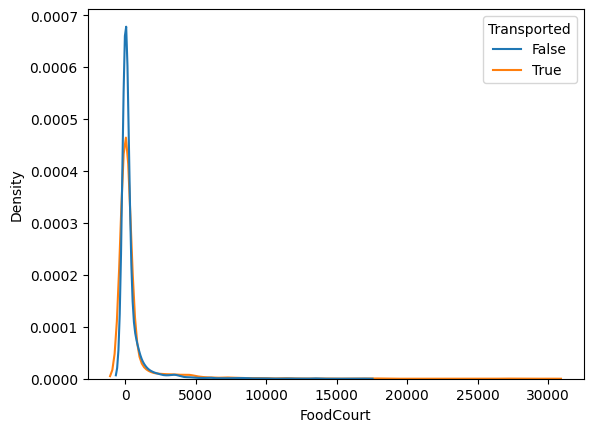

In [1718]:
sns.kdeplot(data=X_train,x="FoodCourt",hue="Transported")
plt.show()

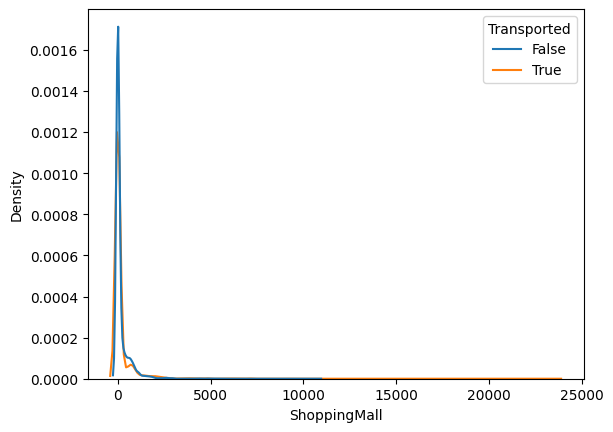

In [1719]:
sns.kdeplot(data=X_train,x="ShoppingMall",hue="Transported")
plt.show()

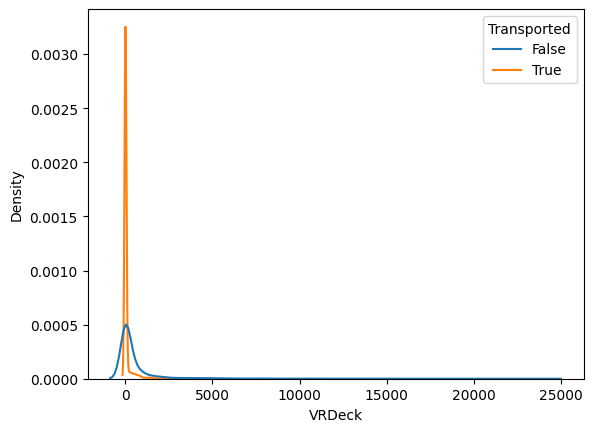

In [1720]:
sns.kdeplot(data=X_train,x="VRDeck",hue="Transported")
plt.show()

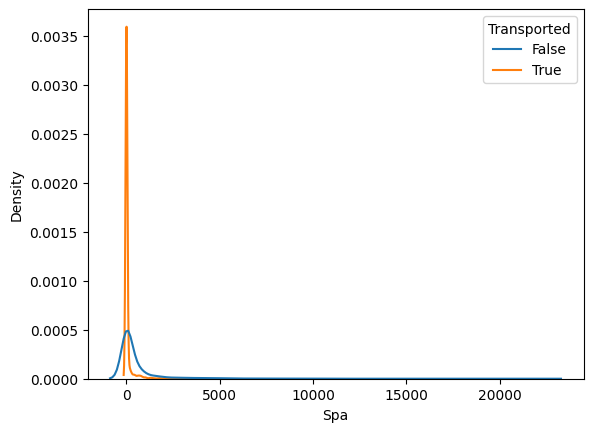

In [1721]:
sns.kdeplot(data=X_train,x="Spa",hue="Transported")
plt.show()

From above it is seen that all of **ShoppingMall,VRDeck,Spa,FoodCourt & RoomService** are highly skewed towards right and need log-transformation to make them roughly Gaussian. 

Also the plots of **VRDeck & Spa** shows significant difference between passengers transported and not and hence might be important features.

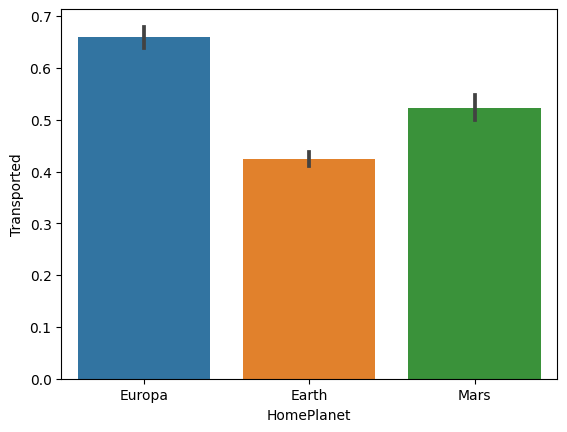

In [1722]:
sns.barplot(X_train,x='HomePlanet',y="Transported")
plt.show()

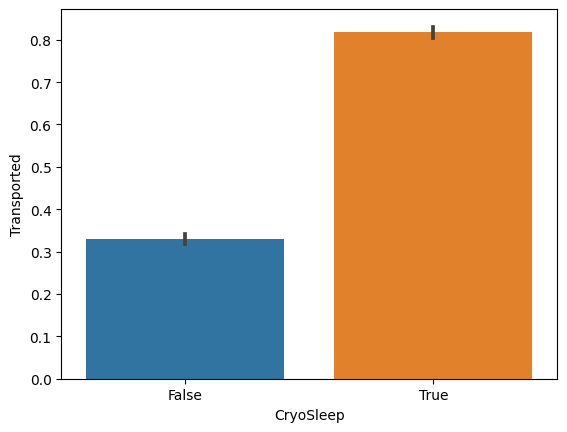

In [1723]:
sns.barplot(X_train,x='CryoSleep',y="Transported")
plt.show()

In [1724]:
X_train['Destination'].unique()

array(['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', nan], dtype=object)

We extract **Destination** planet name for each passenger to check whether that has some influence on passengers transported.

In [1725]:
X_train['Destination'].fillna('U',inplace=True)
X_train['Destination_planet'] = X_train['Destination'].apply(lambda row:row.split('-')[0] if '-' in row else (row.split(' ')[1] if 'Cancri' in row else (row.split(' ')[0] if row else 'U')))

In [1726]:
X_test['Destination'].fillna('U',inplace=True)
X_test['Destination_planet'] = X_test['Destination'].apply(lambda row:row.split('-')[0] if '-' in row else (row.split(' ')[1] if 'Cancri' in row else (row.split(' ')[0] if row else 'U')))

In [1727]:
X_train.Destination_planet.unique()

array(['TRAPPIST', 'PSO J318.5', 'Cancri', 'U'], dtype=object)

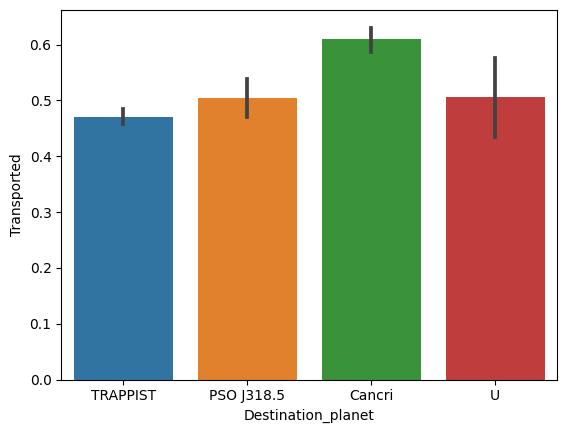

In [1728]:
sns.barplot(data=X_train,x="Destination_planet",y="Transported")
plt.show()

Let us extract the **title** of every passenger to check see if that influences the target.

In [1729]:
names = list(X_train['Name'].unique())
names[:10]

['Maham Ofracculy',
 'Juanna Vines',
 'Altark Susent',
 'Solam Susent',
 'Willy Santantines',
 'Sandie Hinetthews',
 'Billex Jacostaffey',
 'Candra Jacostaffey',
 'Andona Beston',
 'Erraiam Flatic']

In [1730]:
X_train['Name'].fillna('Unknown',inplace=True)
X_test['Name'].fillna('Unknown',inplace=True)

In [1731]:
X_train['title'] = X_train['Name'].apply(lambda row:row.split(' ')[0] if ' ' in row else 'U')
X_test['title'] = X_test['Name'].apply(lambda row:row.split(' ')[0] if ' ' in row else 'U')

In [1732]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,GroupID,PassengerNum,Destination_planet,title
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1,1,TRAPPIST,Maham
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,2,1,TRAPPIST,Juanna
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,3,1,TRAPPIST,Altark
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,3,2,TRAPPIST,Solam
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,4,1,TRAPPIST,Willy


In [1733]:
X_train.isna().sum()

PassengerId             0
HomePlanet            201
CryoSleep             217
Cabin                 199
Destination             0
Age                   179
VIP                   203
RoomService           181
FoodCourt             183
ShoppingMall          208
Spa                   183
VRDeck                188
Name                    0
Transported             0
GroupID                 0
PassengerNum            0
Destination_planet      0
title                   0
dtype: int64

Next we extract **Cabin** values which gets us **deck,num,side**.

In [1734]:
X_train['cabin_deck'] = X_train['Cabin'].str.split('/',expand=True)[0]
X_train['cabin_no'] = X_train['Cabin'].str.split('/',expand=True)[1]
X_train['cabin_port'] = X_train['Cabin'].str.split('/',expand=True)[2]

X_test['cabin_deck'] = X_test['Cabin'].str.split('/',expand=True)[0]
X_test['cabin_no'] = X_test['Cabin'].str.split('/',expand=True)[1]
X_test['cabin_port'] = X_test['Cabin'].str.split('/',expand=True)[2]

In [1735]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,Transported,GroupID,PassengerNum,Destination_planet,title,cabin_deck,cabin_no,cabin_port
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.0,Maham Ofracculy,False,1,1,TRAPPIST,Maham,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,44.0,Juanna Vines,True,2,1,TRAPPIST,Juanna,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,49.0,Altark Susent,False,3,1,TRAPPIST,Altark,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,193.0,Solam Susent,False,3,2,TRAPPIST,Solam,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,2.0,Willy Santantines,True,4,1,TRAPPIST,Willy,F,1,S


In [1736]:
#since there exists NaNs we replace them with suitable values under cabion deck, cabin number & cabin port
X_train['cabin_deck'].fillna('U',inplace=True)
X_train['cabin_port'].fillna('U',inplace=True)
X_train['cabin_no'].fillna(0,inplace=True)

X_test['cabin_deck'].fillna('U',inplace=True)
X_test['cabin_port'].fillna('U',inplace=True)
X_test['cabin_no'].fillna(0,inplace=True)

In [1737]:
X_train['cabin_no']=X_train['cabin_no'].astype(int)
X_test['cabin_no']=X_test['cabin_no'].astype(int)

In [1738]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,Transported,GroupID,PassengerNum,Destination_planet,title,cabin_deck,cabin_no,cabin_port
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.0,Maham Ofracculy,False,1,1,TRAPPIST,Maham,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,44.0,Juanna Vines,True,2,1,TRAPPIST,Juanna,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,49.0,Altark Susent,False,3,1,TRAPPIST,Altark,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,193.0,Solam Susent,False,3,2,TRAPPIST,Solam,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,2.0,Willy Santantines,True,4,1,TRAPPIST,Willy,F,1,S


In [1739]:
X_train['cabin_deck'].isna().any()

False

In [1740]:
X_train.drop(columns=['Cabin','PassengerId','Destination','Name'],inplace=True)
X_test.drop(columns=['Cabin','PassengerId','Destination','Name'],inplace=True)

In [1741]:
X_train.isna().sum()

HomePlanet            201
CryoSleep             217
Age                   179
VIP                   203
RoomService           181
FoodCourt             183
ShoppingMall          208
Spa                   183
VRDeck                188
Transported             0
GroupID                 0
PassengerNum            0
Destination_planet      0
title                   0
cabin_deck              0
cabin_no                0
cabin_port              0
dtype: int64

In [1742]:
X_train['HomePlanet'].fillna('U',inplace=True)
X_test['HomePlanet'].fillna('U',inplace=True)

X_train['CryoSleep'].fillna('U',inplace=True)
X_test['CryoSleep'].fillna('U',inplace=True)

In [1743]:
X_train.pop("Transported")
X_train.head()

,HomePlanet,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupID,PassengerNum,Destination_planet,title,cabin_deck,cabin_no,cabin_port
0,Europa,False,39.0,False,0.0,0.0,0.0,0.0,0.0,1,1,TRAPPIST,Maham,B,0,P
1,Earth,False,24.0,False,109.0,9.0,25.0,549.0,44.0,2,1,TRAPPIST,Juanna,F,0,S
2,Europa,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,3,1,TRAPPIST,Altark,A,0,S
3,Europa,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,3,2,TRAPPIST,Solam,A,0,S
4,Earth,False,16.0,False,303.0,70.0,151.0,565.0,2.0,4,1,TRAPPIST,Willy,F,1,S


In [1744]:
family_members = dict(X_train['GroupID'].value_counts())

In [1745]:
X_train['Family_size'] = X_train['GroupID'].map(family_members).fillna(0)
X_train.head()

,HomePlanet,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupID,PassengerNum,Destination_planet,title,cabin_deck,cabin_no,cabin_port,Family_size
0,Europa,False,39.0,False,0.0,0.0,0.0,0.0,0.0,1,1,TRAPPIST,Maham,B,0,P,1
1,Earth,False,24.0,False,109.0,9.0,25.0,549.0,44.0,2,1,TRAPPIST,Juanna,F,0,S,1
2,Europa,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,3,1,TRAPPIST,Altark,A,0,S,2
3,Europa,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,3,2,TRAPPIST,Solam,A,0,S,2
4,Earth,False,16.0,False,303.0,70.0,151.0,565.0,2.0,4,1,TRAPPIST,Willy,F,1,S,1


In [1746]:
X_test['Family_size'] = X_test['GroupID'].map(dict(X_test['GroupID'].value_counts())).fillna(0)
X_test.head()

,HomePlanet,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupID,PassengerNum,Destination_planet,title,cabin_deck,cabin_no,cabin_port,Family_size
0,Earth,True,27.0,False,0.0,0.0,0.0,0.0,0.0,13,1,TRAPPIST,Nelly,G,3,S,1
1,Earth,False,19.0,False,0.0,9.0,0.0,2823.0,0.0,18,1,TRAPPIST,Lerome,F,4,S,1
2,Europa,True,31.0,False,0.0,0.0,0.0,0.0,0.0,19,1,Cancri,Sabih,C,0,S,1
3,Europa,False,38.0,False,0.0,6652.0,0.0,181.0,585.0,21,1,TRAPPIST,Meratz,C,1,S,1
4,Earth,False,20.0,False,10.0,0.0,635.0,0.0,0.0,23,1,TRAPPIST,Brence,F,5,S,1


In [1747]:
X_test['Family_size'].isna().any()

False

In [1748]:
X_train['Destination_planet'].nunique(),X_train['cabin_deck'].nunique(),X_train['cabin_port'].nunique(),X_train['title'].nunique(),X_train['HomePlanet'].nunique(),X_train['CryoSleep'].nunique(),X_train['VIP'].nunique()

(4, 9, 3, 2707, 4, 3, 2)

In [1749]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   HomePlanet          8693 non-null   object 
 1   CryoSleep           8693 non-null   object 
 2   Age                 8514 non-null   float64
 3   VIP                 8490 non-null   object 
 4   RoomService         8512 non-null   float64
 5   FoodCourt           8510 non-null   float64
 6   ShoppingMall        8485 non-null   float64
 7   Spa                 8510 non-null   float64
 8   VRDeck              8505 non-null   float64
 9   GroupID             8693 non-null   int64  
 10  PassengerNum        8693 non-null   int64  
 11  Destination_planet  8693 non-null   object 
 12  title               8693 non-null   object 
 13  cabin_deck          8693 non-null   object 
 14  cabin_no            8693 non-null   int64  
 15  cabin_port          8693 non-null   object 
 16  Family

#### PREPROCESSING

We perform the following, 
1. Target encoding of Destination Planet, cabin_deck, cabin_port, title, HomePlanet, CryoSleep
2. Ordinal encoding of VIP 
3. Quantile binning numerical features such as Age

In [1750]:
from sklearn.model_selection import StratifiedKFold

In [1751]:
# perform nested cv leakage-safe target encoding
def Target_Encoding(X_tr,X_test,target_col,cols_to_be_target_enc,n_splits,seed):
    '''
    Perform OOF leakage-safe target encoding to create new features.
    '''
    # dataframes to store encoded columns
    te_train = pd.DataFrame(index=X_tr.index)
    te_test = pd.DataFrame(index=X_test.index)

    y = X_tr[target_col]

    skf = StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed)

    for col in cols_to_be_target_enc:
        oof = np.zeros(len(X_tr),dtype=float)

        for tr_idx,va_idx in skf.split(X_tr,y):
            tr_fold = X_tr.iloc[tr_idx]
            va_fold = X_tr.iloc[va_idx]

            mean_map = tr_fold.groupby(col)[target_col].mean()
            oof[va_idx] = va_fold[col].map(mean_map).astype(float).fillna(0)

        te_train[f'te_{col}'] = oof

        #Global map for test
        global_map = X_tr.groupby(col)[target_col].mean()
        te_test[f'te_{col}'] = X_test[col].map(global_map).astype(float).fillna(0)
    
    return te_train,te_test

In [1752]:
def Binning_numerical(X_tr,X_test,cols_to_bin):
    '''
    Function that discretizes numerical feature using quantiles 5,10,15 to extract information at different granular levels
    '''
    bin_train = pd.DataFrame(index=X_tr.index)
    bin_test = pd.DataFrame(index=X_test.index)

    for col in cols_to_bin:
        for q in [5,10,15]:
            try:
                tr_bins,bins = pd.qcut(X_tr[col],q=q,retbins=True,labels=False,duplicates='drop')
                bin_train[f'{col}_bin{q}'] = tr_bins.astype(float)

                bin_test[f'{col}_bin{q}'] = pd.cut(X_test[col],bins=bins,labels=False,include_lowest=True).astype(float)
            except Exception:
                bin_train[f'{col}_bin{q}'] = 0.0
                bin_test[f'{col}_bin{q}'] = 0.0
    
    return bin_train,bin_test

In [1753]:
X_train = X_train.join(y_train)

In [1754]:
# target encode
te_train,te_test = Target_Encoding(X_train,X_test,"Transported",['Destination_planet','cabin_port','cabin_deck','title','HomePlanet','CryoSleep'],7,42)

In [1755]:
X_train = X_train.join(te_train)
X_test = X_test.join(te_test)
X_train.pop("Transported")

0       False
1        True
2       False
3       False
4        True
        ...  
8688    False
8689    False
8690     True
8691    False
8692     True
Name: Transported, Length: 8693, dtype: bool

In [1756]:
X_train.head()

,HomePlanet,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupID,...,cabin_deck,cabin_no,cabin_port,Family_size,te_Destination_planet,te_cabin_port,te_cabin_deck,te_title,te_HomePlanet,te_CryoSleep
0,Europa,False,39.0,False,0.0,0.0,0.0,0.0,0.0,1,...,B,0,P,1,0.471784,0.452956,0.744395,0.500000,0.668842,0.327167
1,Earth,False,24.0,False,109.0,9.0,25.0,549.0,44.0,2,...,F,0,S,1,0.471110,0.554342,0.436620,0.600000,0.424923,0.328832
2,Europa,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,3,...,A,0,S,2,0.471110,0.554342,0.493333,0.000000,0.658351,0.328832
3,Europa,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,3,...,A,0,S,2,0.471110,0.554342,0.493333,1.000000,0.658351,0.328832
4,Earth,False,16.0,False,303.0,70.0,151.0,565.0,2.0,4,...,F,1,S,1,0.470171,0.554953,0.439698,0.571429,0.424311,0.329250


In [1757]:
# X_train['total_expenditure'] = X_train['RoomService']+X_train['FoodCourt']+X_train['ShoppingMall']+X_train['Spa']+X_train['VRDeck']
# X_test['total_expenditure'] = X_test['RoomService']+X_test['FoodCourt']+X_test['ShoppingMall']+X_test['Spa']+X_test['VRDeck']

In [1758]:
X_train.columns

Index(['HomePlanet', 'CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt',
       'ShoppingMall', 'Spa', 'VRDeck', 'GroupID', 'PassengerNum',
       'Destination_planet', 'title', 'cabin_deck', 'cabin_no', 'cabin_port',
       'Family_size', 'te_Destination_planet', 'te_cabin_port',
       'te_cabin_deck', 'te_title', 'te_HomePlanet', 'te_CryoSleep'],
      dtype='object')

In [1759]:
def transform_num(X):
    res = np.log1p(X[:,0])
    return res.reshape(-1,1)

In [1760]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

num_transform_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    FunctionTransformer(transform_num,feature_names_out='one-to-one'),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder()
)

preprocessing = ColumnTransformer([
    ('num_process',num_pipeline,['te_HomePlanet','te_CryoSleep','GroupID','te_Destination_planet','te_title','te_cabin_deck','cabin_no','te_cabin_port','Age','Family_size']),
    ('cat_',cat_pipeline,['VIP']),
    ('log1_',num_transform_pipeline,['RoomService']),
    ('log2_',num_transform_pipeline,['FoodCourt']),
    ('log3_',num_transform_pipeline,['ShoppingMall']),
    ('log4_',num_transform_pipeline,['Spa']),
    ('log5_',num_transform_pipeline,['VRDeck'])
])

In [1761]:
def Preprocessing(X_tr,X_test,target,n_splits,seed):
    '''
    Function to impute missing values using simple imputer with strategy median across different columns.
    '''
    skf = StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed)
    y= X_tr[target]

    # fit on partial data to infer the shape
    sample_transformed = preprocessing.fit_transform(X_tr.iloc[:len(X_tr)//2,:])
    oof_vals = np.zeros((len(X_tr),sample_transformed.shape[1]))


    for tr_idx,val_idx in skf.split(X_tr,y):
        tr_fold = X_tr.iloc[tr_idx]
        va_fold = X_tr.iloc[val_idx]
        # simp_imputer = SimpleImputer(strategy='median')
        preprocessing.fit(tr_fold)
        oof_vals[val_idx] = preprocessing.transform(va_fold)

    preprocessing.fit(X_tr)
    X_test_transformed = preprocessing.transform(X_test)
    X_test = pd.DataFrame(X_test_transformed,columns=preprocessing.get_feature_names_out(),index=X_test.index)

    X_tr = pd.DataFrame(oof_vals,columns=preprocessing.get_feature_names_out(),index=X_tr.index)
    
    return X_tr,X_test

In [1762]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   HomePlanet             8693 non-null   object 
 1   CryoSleep              8693 non-null   object 
 2   Age                    8514 non-null   float64
 3   VIP                    8490 non-null   object 
 4   RoomService            8512 non-null   float64
 5   FoodCourt              8510 non-null   float64
 6   ShoppingMall           8485 non-null   float64
 7   Spa                    8510 non-null   float64
 8   VRDeck                 8505 non-null   float64
 9   GroupID                8693 non-null   int64  
 10  PassengerNum           8693 non-null   int64  
 11  Destination_planet     8693 non-null   object 
 12  title                  8693 non-null   object 
 13  cabin_deck             8693 non-null   object 
 14  cabin_no               8693 non-null   int64  
 15  cabi

In [1763]:
X_train.columns

Index(['HomePlanet', 'CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt',
       'ShoppingMall', 'Spa', 'VRDeck', 'GroupID', 'PassengerNum',
       'Destination_planet', 'title', 'cabin_deck', 'cabin_no', 'cabin_port',
       'Family_size', 'te_Destination_planet', 'te_cabin_port',
       'te_cabin_deck', 'te_title', 'te_HomePlanet', 'te_CryoSleep'],
      dtype='object')

In [1764]:
X_train = X_train.join(y_train)

In [1765]:
X_train_preprocessed,X_test_preprocessed = Preprocessing(X_train,X_test,'Transported',7,42)

In [1548]:
# numquant_bin_train,num_quant_bin_test = Binning_numerical(X_train_preprocessed,X_test_preprocessed,['num_process__Age'])
# X_train_preprocessed = X_train_preprocessed.join(numquant_bin_train)
# X_test_preprocessed = X_test_preprocessed.join(num_quant_bin_test)

In [1766]:
X_train_preprocessed.head()

,num_process__te_HomePlanet,num_process__te_CryoSleep,num_process__GroupID,num_process__te_Destination_planet,num_process__te_title,num_process__te_cabin_deck,num_process__cabin_no,num_process__te_cabin_port,num_process__Age,num_process__Family_size,cat___VIP,log1___RoomService,log2___FoodCourt,log3___ShoppingMall,log4___Spa,log5___VRDeck
0,1.716838,-0.766569,-1.733250,-0.570404,0.141948,2.267695,-1.141080,-0.982525,0.708121,-0.650588,0.0,-0.666844,-0.678273,-0.660172,-0.693780,-0.673553
1,-0.819356,-0.753804,-1.735467,-0.578391,0.414910,-0.633309,-1.140292,0.991409,-0.335215,-0.650448,0.0,1.023544,0.082449,0.592242,1.555303,0.687289
2,1.586367,-0.753804,-1.735093,-0.578391,-1.247626,-0.099018,-1.140292,0.991409,2.061796,-0.025740,1.0,0.692588,2.049905,-0.658398,2.447971,0.724999
3,1.586367,-0.753804,-1.735093,-0.578391,1.523268,-0.099018,-1.140292,0.991409,0.299288,-0.025740,0.0,-0.674226,1.707073,1.613605,2.197714,1.210275
4,-0.808924,-0.755479,-1.729741,-0.603305,0.341976,-0.601415,-1.138568,0.995717,-0.895778,-0.646774,0.0,1.405043,0.751747,1.282964,1.576190,-0.277663


#### CHECKING INFLUENCE OF TRANSFORMED FEATURES ON TARGET VARIABLE

In [1767]:
# compute mutual information
num_cols = list(X_train_preprocessed.select_dtypes(include=np.number))
mi_result=mutual_info_classif(X_train_preprocessed[num_cols],y_train)
mi_result = pd.Series(mi_result)
mi_result.index = num_cols
mi_result.sort_values(ascending=False)

num_process__te_CryoSleep             0.118834
log4___Spa                            0.076932
log1___RoomService                    0.073593
log5___VRDeck                         0.059218
log3___ShoppingMall                   0.052887
log2___FoodCourt                      0.048385
num_process__te_cabin_deck            0.028351
num_process__te_HomePlanet            0.016927
num_process__te_Destination_planet    0.012431
num_process__Age                      0.012398
num_process__cabin_no                 0.009409
num_process__Family_size              0.006649
num_process__te_cabin_port            0.002681
num_process__te_title                 0.002021
num_process__GroupID                  0.000695
cat___VIP                             0.000000
dtype: float64

In [1768]:
X_train_preprocessed = X_train_preprocessed.join(y_train)
corr_res = X_train_preprocessed.corr()
corr_res['Transported'].sort_values(ascending=False)

Transported                           1.000000
num_process__te_CryoSleep             0.462418
num_process__te_cabin_deck            0.206736
num_process__te_HomePlanet            0.191222
num_process__te_Destination_planet    0.105084
num_process__te_cabin_port            0.100094
num_process__Family_size              0.082529
num_process__te_title                 0.042487
num_process__GroupID                  0.021487
cat___VIP                            -0.037261
num_process__cabin_no                -0.043756
num_process__Age                     -0.074260
log2___FoodCourt                     -0.129602
log3___ShoppingMall                  -0.171311
log5___VRDeck                        -0.331484
log1___RoomService                   -0.355015
log4___Spa                           -0.356953
Name: Transported, dtype: float64

In [1769]:
X_train_preprocessed.pop("Transported")

0       False
1        True
2       False
3       False
4        True
        ...  
8688    False
8689    False
8690     True
8691    False
8692     True
Name: Transported, Length: 8693, dtype: bool

In [1770]:
X_train_preprocessed.columns

Index(['num_process__te_HomePlanet', 'num_process__te_CryoSleep',
       'num_process__GroupID', 'num_process__te_Destination_planet',
       'num_process__te_title', 'num_process__te_cabin_deck',
       'num_process__cabin_no', 'num_process__te_cabin_port',
       'num_process__Age', 'num_process__Family_size', 'cat___VIP',
       'log1___RoomService', 'log2___FoodCourt', 'log3___ShoppingMall',
       'log4___Spa', 'log5___VRDeck'],
      dtype='object')

### TESTING ML MODELS
Now we run the initial predictors coupled with the engineered ones on the below ML models to see how they perform. 

The models considered are, 
1. Random Forest
2. XGBoost

In [1771]:
from sklearn.base import clone

In [1772]:
def oof_auc_check_for_model(X,y,model_pipeline):
    '''
    Function to check for model performance using OOF CV.
    '''
    skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True)
    oof_score = np.zeros(len(X),dtype=float)
    acc_results = []

    for tr_idx,val_idx in skf.split(X,y):
        tr_fold,y_tr = X.iloc[tr_idx],y[tr_idx]
        val_fold,y_val = X.iloc[val_idx],y[val_idx]

        model = clone(model_pipeline)
        
        model.fit(tr_fold,y_tr)
        oof_score[val_idx] = model.predict_proba(val_fold)[:,1].astype(float)

        fold_pred = model.predict(val_fold)
        acc_score = accuracy_score(y_val,fold_pred)

        acc_results.append(acc_score)
        
    
    return roc_auc_score(y,oof_score),acc_results

In [1773]:
def Learning_Curve(model_pipeline,X_tr,y_tr):
    '''
    Function to plot learning curve for a model.
    '''
    train_sizes,train_scores,valid_scores = learning_curve(model_pipeline,X_tr,y_tr,train_sizes=np.linspace(0.01,1,40),cv=StratifiedKFold(random_state=42,shuffle=True,n_splits=5),scoring='neg_log_loss')
    train_errors = -train_scores.mean(axis=1)
    valid_errors = -valid_scores.mean(axis=1)

    plt.plot(train_sizes,train_errors,"r-+",linewidth=2,label="train")
    plt.plot(train_sizes,valid_errors,"b-+",linewidth=2,label="valid")
    plt.xlabel("Training set size")
    plt.ylabel("Log Loss")
    plt.show()

#### BASELINE XGBOOST MODEL

In [1774]:
# try testing on a baseline xgb model which usually performs better than randomforest
baseline_xgb_pipeline = Pipeline([
    ('baseline_xgbmodel',XGBClassifier(objective='binary:logistic',random_state=42))
])

baseline_xgb_result,acc_result = oof_auc_check_for_model(X_train_preprocessed,y_train,baseline_xgb_pipeline)
print(f'ROC AUC: {baseline_xgb_result}, Accuracy mean & std: {np.array(acc_result).mean()} and {np.array(acc_result).std()}')

ROC AUC: 0.8892789026772967, Accuracy mean & std: 0.7973092746052617 and 0.0067798917848629695


In [1775]:
# train baseline logreg model on full dataset to fit parameters
baseline_xgb_pipeline.fit(X_train_preprocessed,y_train)

y_pred_prob_xgb_base_on_train = baseline_xgb_pipeline.predict(X_train_preprocessed)
print(f"Accuracy on train set is : {accuracy_score(y_train,y_pred_prob_xgb_base_on_train)*100}%")

Accuracy on train set is : 96.06580006902105%


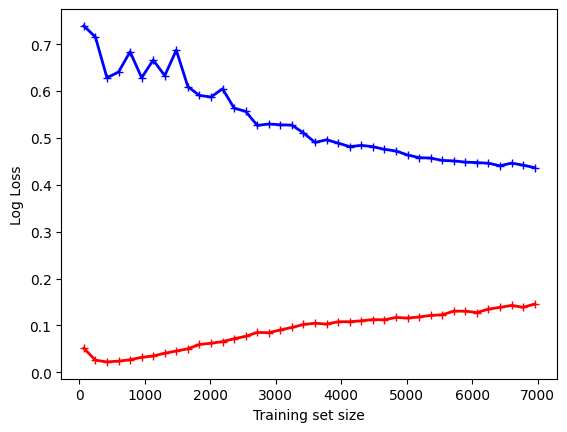

In [1776]:
Learning_Curve(baseline_xgb_pipeline,X_train_preprocessed,y_train)

In [1777]:
# predict on test set
y_pred_test = baseline_xgb_pipeline.predict(X_test_preprocessed)
y_pred_test = y_pred_test.astype(bool)

In [1572]:
# save results
# df_beseline_xgb_results = pd.DataFrame(data=list(zip(spaceship_test_df['PassengerId'],y_pred_test)),columns=['PassengerId','Transported'])
# df_beseline_xgb_results.to_csv(path_or_buf="./Predictions/Spaceship_Titanic/xgb_result/XGB_besemodel_0_251125.csv",index=False)

#### BASELINE RANDOM FOREST

In [1579]:
randforest_model = RandomForestClassifier(random_state=42,max_depth=5)

# train & test random forest model using k-fold cv
baseline_randforest_result,oof_result = oof_auc_check_for_model(X_train_preprocessed,y_train,randforest_model)
print(f'OOF-CV ROC_AUC result is: {baseline_randforest_result}. Foldwise mean & std are: {np.array(oof_result).mean()}, {np.array(oof_result).std()}')

OOF-CV ROC_AUC result is: 0.8647419653836441. Foldwise mean & std are: 0.7754506213972953, 0.006502697281782566


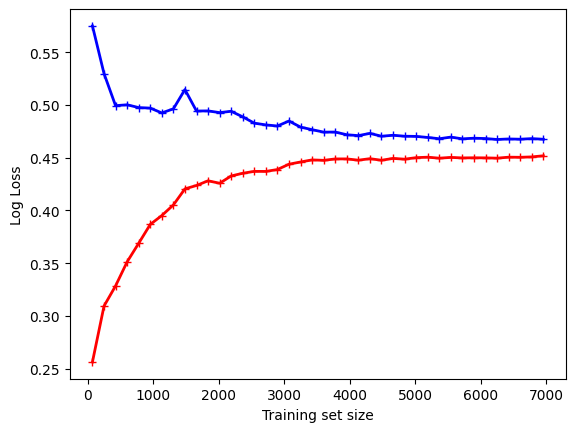

In [1580]:
Learning_Curve(randforest_model,X_train_preprocessed,y_train)

In [1581]:
# train baseline logreg model on full dataset to fit parameters
randforest_model.fit(X_train_preprocessed,y_train)

y_pred_randforestbase_on_train = randforest_model.predict(X_train_preprocessed)
print(f"Accuracy on train set is : {accuracy_score(y_train,y_pred_randforestbase_on_train)*100}%")

Accuracy on train set is : 78.26987231105487%


#### BASELINE ADABOOST

In [1778]:
adaboost_model = AdaBoostClassifier(random_state=42)

# train & test random forest model using k-fold cv
baseline_adaboost_result,oof_result = oof_auc_check_for_model(X_train_preprocessed,y_train,adaboost_model)
print(f'OOF-CV ROC_AUC result is: {baseline_adaboost_result}. Foldwise mean & std are: {np.array(oof_result).mean()}, {np.array(oof_result).std()}')


OOF-CV ROC_AUC result is: 0.8610438424080795. Foldwise mean & std are: 0.7767167088739941, 0.003333983326597299


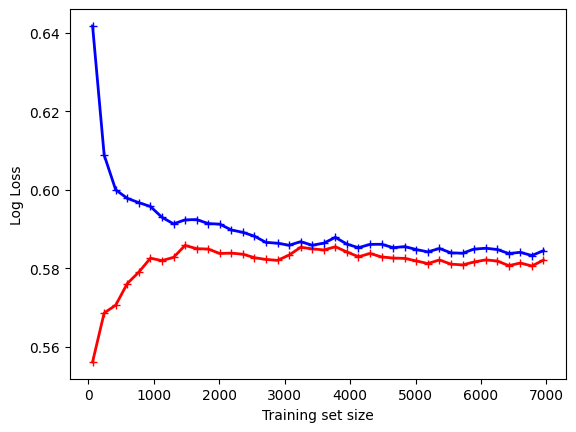

In [1779]:
Learning_Curve(adaboost_model,X_train_preprocessed,y_train)

In [1780]:
# train baseline logreg model on full dataset to fit parameters
adaboost_model.fit(X_train_preprocessed,y_train)

y_pred_adaboostbase_on_train = adaboost_model.predict(X_train_preprocessed)
print(f"Accuracy on train set is : {accuracy_score(y_train,y_pred_adaboostbase_on_train)*100}%")

Accuracy on train set is : 78.5459565167376%


#### HYPERPARAMTER TUNED ADABOOST

In [1781]:
# tuning parametrs of xgb model to achieve improved performance
adaboost_model = AdaBoostClassifier(random_state=42,estimator=DecisionTreeClassifier(random_state=42))
adaboost_param_grid = [
    {
     'n_estimators':randint(30,1001),
     'learning_rate':uniform(0.01,0.99),
     'estimator__max_depth':randint(5,8),
     'estimator__min_samples_leaf':randint(5,11),
     'estimator__min_samples_split': randint(2, 20)}
     ]

skf = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
adaboost_rnd_search = RandomizedSearchCV(adaboost_model,adaboost_param_grid,n_iter=5,scoring='accuracy',cv=skf,random_state=42)

# fit data to diff randomforest models defined by varying hyperparameters above & carry out cv to evaluate performance
adaboost_rnd_search.fit(X_train_preprocessed,y_train)

,estimator,AdaBoostClass...ndom_state=42)
,param_distributions,"[{'estimator__max_depth': <scipy.stats....t 0x349196290>, 'estimator__min_samples_leaf': <scipy.stats....t 0x116c97df0>, 'estimator__min_samples_split': <scipy.stats....t 0x3591b4ee0>, 'learning_rate': <scipy.stats....t 0x347ef0dc0>, ...}]"
,n_iter,5
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [1782]:
adaboost_rnd_search.best_params_
# train best xgb model above and run predictions
adaboost_best_model = adaboost_rnd_search.best_estimator_

In [1783]:
adaboost_rnd_search.best_score_

0.8015651865811702

In [1784]:
# check performance on train & valid sets
y_pred_adaboost_tuned_on_train = adaboost_best_model.predict(X_train_preprocessed)
print(f"Accuracy on train set is : {accuracy_score(y_train,y_pred_adaboost_tuned_on_train)*100}%")

Accuracy on train set is : 85.16047394455309%


In [1625]:
y_pred_adaboost_best_model = adaboost_best_model.predict(X_test_preprocessed)
y_pred_adaboost_best_model = y_pred_adaboost_best_model.astype(bool)

In [1602]:
# save results
# df_tuned_adaboost = pd.DataFrame(data=list(zip(spaceship_test_df['PassengerId'],y_pred_adaboost_best_model)),columns=['PassengerId','Transported'])
# df_tuned_adaboost.to_csv(path_or_buf="./Predictions/Spaceship_Titanic/Adaboost_results/Adaboost_tuned_0_031225.csv",index=False)

#### HYPER PARAMETER TUNED XGBOOST
Here we perform hyper parameter tuning of XGBoost model alongside finding the optimal set of boosted rounds that minimizes the train/validation error using **RandomisedSearchCV**.

In [1603]:
X_tr_preprocessed,X_val_preprocessed,y_tr,y_val = train_test_split(X_train_preprocessed,y_train,test_size=0.2,random_state=42)

In [1604]:
# tuning parametrs of xgb model to achieve improved performance
xgb_model = XGBClassifier(random_state=42,objective='binary:logistic',n_estimators=20000,eval_metric='logloss',verbosity=0,early_stopping_rounds=50)
xgb_param_grid = [
    {
     'max_depth':randint(3,12),
     'colsample_bylevel':uniform(0.5,0.9),
     'lambda':uniform(0,1.0),
     'eta':uniform(0.01,0.3),
     'subsample':uniform(0.3,0.7),
     'alpha':uniform(0,1.0)}]

skf = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
xgb_rnd_search = RandomizedSearchCV(xgb_model,xgb_param_grid,n_iter=10,scoring='accuracy',cv=skf,random_state=42)
fit_params = {
    'eval_set':[(X_val_preprocessed,y_val)]
}
# fit data to diff randomforest models defined by varying hyperparameters above & carry out cv to evaluate performance
xgb_rnd_search.fit(X_tr_preprocessed,y_tr,**fit_params)

[0]	validation_0-logloss:0.65334
[1]	validation_0-logloss:0.62045
[2]	validation_0-logloss:0.59334
[3]	validation_0-logloss:0.57228
[4]	validation_0-logloss:0.55475
[5]	validation_0-logloss:0.53623
[6]	validation_0-logloss:0.52205
[7]	validation_0-logloss:0.51029
[8]	validation_0-logloss:0.49881
[9]	validation_0-logloss:0.48997
[10]	validation_0-logloss:0.48285
[11]	validation_0-logloss:0.47701
[12]	validation_0-logloss:0.47053
[13]	validation_0-logloss:0.46647
[14]	validation_0-logloss:0.46231
[15]	validation_0-logloss:0.45745
[16]	validation_0-logloss:0.45421
[17]	validation_0-logloss:0.45059
[18]	validation_0-logloss:0.44823
[19]	validation_0-logloss:0.44654
[20]	validation_0-logloss:0.44259
[21]	validation_0-logloss:0.44162
[22]	validation_0-logloss:0.44047
[23]	validation_0-logloss:0.43984
[24]	validation_0-logloss:0.43817
[25]	validation_0-logloss:0.43787
[26]	validation_0-logloss:0.43602
[27]	validation_0-logloss:0.43526
[28]	validation_0-logloss:0.43559
[29]	validation_0-loglos

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
21 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packa

[81]	validation_0-logloss:0.47732
[82]	validation_0-logloss:0.47633
[83]	validation_0-logloss:0.47528
[84]	validation_0-logloss:0.47422
[85]	validation_0-logloss:0.47327
[86]	validation_0-logloss:0.47249
[87]	validation_0-logloss:0.47168
[88]	validation_0-logloss:0.47079
[89]	validation_0-logloss:0.46994
[90]	validation_0-logloss:0.46896
[91]	validation_0-logloss:0.46815
[92]	validation_0-logloss:0.46738
[93]	validation_0-logloss:0.46654
[94]	validation_0-logloss:0.46586
[95]	validation_0-logloss:0.46501
[96]	validation_0-logloss:0.46431
[97]	validation_0-logloss:0.46345
[98]	validation_0-logloss:0.46267
[99]	validation_0-logloss:0.46199
[100]	validation_0-logloss:0.46147
[101]	validation_0-logloss:0.46075
[102]	validation_0-logloss:0.46011
[103]	validation_0-logloss:0.45937
[104]	validation_0-logloss:0.45887
[105]	validation_0-logloss:0.45794
[106]	validation_0-logloss:0.45754
[107]	validation_0-logloss:0.45663
[108]	validation_0-logloss:0.45604
[109]	validation_0-logloss:0.45539
[110

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"[{'alpha': <scipy.stats....t 0x35c3f2ad0>, 'colsample_bylevel': <scipy.stats....t 0x1134ee530>, 'eta': <scipy.stats....t 0x35c3f2410>, 'lambda': <scipy.stats....t 0x35c3f0640>, ...}]"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [1605]:
xgb_rnd_search.best_params_

{'alpha': 0.6116531604882809,
 'colsample_bylevel': 0.5063596746977457,
 'eta': 0.01691872751242473,
 'lambda': 0.5247746602583891,
 'max_depth': 5,
 'subsample': 0.5677233938870139}

In [1606]:
# train best xgb model above and run predictions
xgb_best_model = xgb_rnd_search.best_estimator_

In [1607]:
xgb_best_model.best_iteration

714

In [1608]:
# check performance on train & valid sets
y_pred_xgb_tuned_on_train = xgb_best_model.predict(X_train_preprocessed)
print(f"Accuracy on train set is : {accuracy_score(y_train,y_pred_xgb_tuned_on_train)*100}%")

Accuracy on train set is : 86.3223283101346%


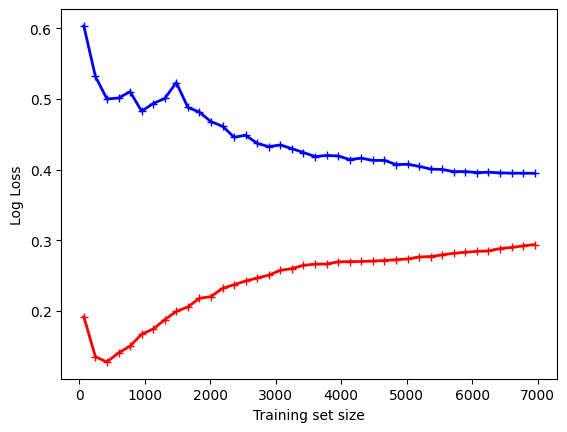

In [1609]:
xgb_best_for_lc = XGBClassifier(random_state=42,objective='binary:logistic',n_estimators=714,verbosity=0,**xgb_rnd_search.best_params_)
Learning_Curve(xgb_best_for_lc,X_train_preprocessed,y_train)

In [1610]:
y_pred_xgb_best_model = xgb_best_model.predict(X_test_preprocessed)
y_pred_xgb_best_model = y_pred_xgb_best_model.astype(bool)

In [1469]:
# save results
# df_paramtuned_xgb_results = pd.DataFrame(data=list(zip(spaceship_test_df['PassengerId'],y_pred_xgb_best_model)),columns=['PassengerId','Transported'])
# df_paramtuned_xgb_results.to_csv(path_or_buf="./Predictions/Spaceship_Titanic/xgb_result/XGB_tuned_0_011225.csv",index=False)

XGboost with **{'xgbclassifier__alpha': 1.5,'xgbclassifier__colsample_bylevel': 0.5,'xgbclassifier__lambda': 1.1,'xgbclassifier__max_depth': 6,'xgbclassifier__n_estimators': 64** as parameters yield **80.453%** as accuracy.

#### HYPER PARAMETER TUNED RANDOMFOREST

In [1611]:
randforest_model = RandomForestClassifier(random_state=42)
param_grid_randforest = [
    {
        'max_depth':randint(low=3,high=11),
        'n_estimators':randint(low=100,high=2001),
        'min_samples_leaf':randint(low=3,high=11),
        'max_features':uniform(0.3,1.0)
    }
]

skf = StratifiedKFold(n_splits=3,random_state=42,shuffle=True)
rnd_search = RandomizedSearchCV(randforest_model,param_grid_randforest,n_iter=10,scoring='accuracy',cv=skf,random_state=42)

#fit data to different randomforests formed
rnd_search.fit(X_train_preprocessed,y_train)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
9 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/sit

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"[{'max_depth': <scipy.stats....t 0x35c3f3940>, 'max_features': <scipy.stats....t 0x35b3c3f10>, 'min_samples_leaf': <scipy.stats....t 0x35c3f2200>, 'n_estimators': <scipy.stats....t 0x35c3f1e10>}]"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [1612]:
# train best xgb model above and run predictions
randforest_best_model = rnd_search.best_estimator_
rnd_search.best_params_

{'max_depth': 9,
 'max_features': 0.35808361216819945,
 'min_samples_leaf': 9,
 'n_estimators': 1223}

In [1613]:
rnd_search.best_score_

0.798458762739653

In [1614]:
# check performance on train & valid sets
y_pred_randforest_tuned_on_train = randforest_best_model.predict(X_train_preprocessed)
print(f"Accuracy on train set is : {accuracy_score(y_train,y_pred_randforest_tuned_on_train)*100}%")

Accuracy on train set is : 84.47026343034626%


In [1111]:
# MAX_ESTIMATORS = 20000
# EARLY_STOPPING_ROUNDS = 50
# NUM_FOLD = 7
# # base params for baseline xgb model
# BASE_PARAMS = {
#     'tree_method': 'hist',
#     'device': 'cpu',            
#     'predictor': 'auto',
#     'eval_metric': 'auc',
#     'objective': 'binary:logistic',
#     'subsample': 1.0,
#     'colsample_bytree': 1.0,
#     'colsample_bylevel': 0.5,
#     'colsample_bynode': 1.0,
#     'gamma': 0.0,
#     'scale_pos_weight': 1.0
# }
# SEED = 42

In [1118]:
# def Perform_CV_Rounds(X_tr,features,target,base_params=BASE_PARAMS):
#     '''
#     This functions helps output optimal number of estimators for baseline XGB model using CV with a probe.
#     '''

#     y = X_tr.pop(target)

#     # setup XGB suitable data matrix which is memory efficient and helps in faster training of model
#     dtrain = xgb.DMatrix(data=X_tr[features],label=y,enable_categorical=True)

#     cv = xgb.cv(
#         params = base_params,
#         dtrain = dtrain,
#         nfold = NUM_FOLD,
#         num_boost_round = MAX_ESTIMATORS,
#         verbose_eval = False,
#         early_stopping_rounds = EARLY_STOPPING_ROUNDS,
#         seed = SEED,
#         shuffle = True,
#         stratified = True
#     )
#     best_round = cv['test-auc-mean'].idxmax()
#     best_auc = cv.loc[best_round,'test-auc-mean']

#     print(f'Best round: {best_round}')
#     print(f'Best ROC AUC: {best_auc}')

#     return best_round,best_auc

In [1113]:
# # base for xgb.cv
# base_for_cv = BASE_PARAMS.copy()
# # probe = dict(max_leaves=5,min_child_weight=89,reg_alpha=0.5,reg_lambda=1.5)
# probe = dict(max_depth=6,reg_alpha=1.5,reg_lambda=1.1)
# base_for_cv.update(probe)

In [1114]:
# target = "Transported"

In [1115]:
# common_cols = list(X_train_preprocessed.columns)

In [1116]:
# X_train_preprocessed = X_train_preprocessed.join(y_train)

In [1117]:
# X_train_preprocessed.columns

Index(['num_process__te_HomePlanet', 'num_process__te_CryoSleep',
       'num_process__GroupID', 'num_process__te_Destination_planet',
       'num_process__te_title', 'num_process__te_cabin_deck',
       'num_process__cabin_no', 'num_process__te_cabin_port',
       'num_process__Age', 'cat___VIP', 'log1___RoomService',
       'log2___FoodCourt', 'log3___ShoppingMall', 'log4___Spa',
       'log5___VRDeck', 'Transported'],
      dtype='object')

In [1120]:
# best_round,best_auc = Perform_CV_Rounds(X_train_preprocessed,common_cols,target,base_for_cv)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/training.py:225: UserWarning: [23:51:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  return getattr(self.bst, name)(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/training.py:231: UserWarning: [23:51:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  self.bst.update(self.dtrain, iteration, fobj)


Best round: 31
Best ROC AUC: 0.8943352393501189


In [1363]:
# xgb_model_pipeline = make_pipeline(XGBClassifier(random_state=42,objective='binary:logistic',n_estimators=36,max_depth=7,reg_alpha=1.2,reg_lambda=1.0,colsample_bylevel=0.5))
# tuned_xgb_result,acc_result = oof_auc_check_for_model(X_train_preprocessed,y_train,xgb_model_pipeline)
# print(f'AUC ROC on valid set:{tuned_xgb_result}, Accuracy mean & std: {np.array(acc_result).mean()} and {np.array(acc_result).std()}')

AUC ROC on valid set:0.8929897565357601, Accuracy mean & std: 0.8004141104598954 and 0.0038677383069225667


In [1364]:
# # fit pipeline
# xgb_model_pipeline.fit(X_train_preprocessed_shuffled,y_train_shuffled)

# # check performance on train & valid sets
# y_pred_xgb_tuned_on_train = xgb_model_pipeline.predict(X_train_preprocessed_shuffled)
# print(f"Accuracy on train set is : {accuracy_score(y_train_shuffled,y_pred_xgb_tuned_on_train)*100}%")

Accuracy on train set is : 90.59012998964684%


In [1124]:
# y_pred_xgb_tuned_model = xgb_model_pipeline.predict(X_test_preprocessed)
# y_pred_xgb_tuned_model = y_pred_xgb_tuned_model.astype(bool)

In [1125]:
# save results
# df_paramtuned_xgb_results = pd.DataFrame(data=list(zip(spaceship_test_df['PassengerId'],y_pred_xgb_tuned_model)),columns=['PassengerId','Transported'])
# df_paramtuned_xgb_results.to_csv(path_or_buf="./Predictions/Spaceship_Titanic/xgb_result/XGB_0_251125.csv",index=False)

1. **XGBoost** model achieves an accuracy of **80.173%** with **n_estimators=36,max_depth=6,reg_alpha=1.2,reg_lambda=1.0,colsample_bylevel=0.5**. 

2. **XGBoost** model achieves an accuracy of **80.593%** with **n_estimators=36,max_depth=7,reg_alpha=1.2,reg_lambda=1.0,colsample_bylevel=0.5**. 

#### VOTING CLASSIFIER

In [1631]:
voting_clf = VotingClassifier(estimators=[
    ('rf',RandomForestClassifier(**rnd_search.best_params_)),
    ('xgb',XGBClassifier(**xgb_rnd_search.best_params_)),
    ('adboost',AdaBoostClassifier(random_state=42,estimator=adaboost_best_model.get_params()['estimator'],n_estimators=adaboost_best_model.get_params()['n_estimators'],learning_rate=adaboost_best_model.get_params()['learning_rate']))
],voting='soft')

In [1632]:
# check for OOF performance for voting classifier
votingclf_result,oof_result = oof_auc_check_for_model(X_train_preprocessed,y_train,voting_clf)
print(f'OOF-CV ROC_AUC result is: {votingclf_result}. Foldwise mean & std are: {np.array(oof_result).mean()}, {np.array(oof_result).std()}')

OOF-CV ROC_AUC result is: 0.8908833644679734. Foldwise mean & std are: 0.8006438630193008, 0.006368658727635621


In [1633]:
# check performance on train & valid sets
voting_clf.fit(X_train_preprocessed,y_train)

y_pred_votingclf_on_train = voting_clf.predict(X_train_preprocessed)
print(f"Accuracy on train set is : {accuracy_score(y_train,y_pred_votingclf_on_train)*100}%")

Accuracy on train set is : 83.37743011618544%


In [1634]:
# predict on test set
y_pred_voting_clf_model = voting_clf.predict(X_test_preprocessed)
y_pred_voting_clf_model = y_pred_voting_clf_model.astype(bool)

In [1635]:
# save results
# df_voting_clf_results = pd.DataFrame(data=list(zip(spaceship_test_df['PassengerId'],y_pred_voting_clf_model)),columns=['PassengerId','Transported'])
# df_voting_clf_results.to_csv(path_or_buf="./Predictions/Spaceship_Titanic/voting_clf_result/Voting_clf_0_051225.csv",index=False)

#### STACKING ENSEMBLE
We use **Stacking Ensemble** with the following structure, 
1. Preddictors - Tuned XGB, RandomForest & Adaboost. 
2. Blender - Random Forest with max depth of 5.

In [1640]:
stacking_clf = StackingClassifier(estimators=[
    ('rf',RandomForestClassifier(**rnd_search.best_params_)),
    ('xgb',XGBClassifier(**xgb_rnd_search.best_params_)),
    ('adboost',AdaBoostClassifier(random_state=42,estimator=adaboost_best_model.get_params()['estimator'],n_estimators=adaboost_best_model.get_params()['n_estimators'],learning_rate=adaboost_best_model.get_params()['learning_rate']))
],final_estimator=LogisticRegression(random_state=42))

In [1641]:
# check for OOF performance for stacking classifier
stacking_clf_result,oof_result = oof_auc_check_for_model(X_train_preprocessed,y_train,stacking_clf)
print(f'OOF-CV ROC_AUC result is: {stacking_clf_result}. Foldwise mean & std are: {np.array(oof_result).mean()}, {np.array(oof_result).std()}')

OOF-CV ROC_AUC result is: 0.8848486612986982. Foldwise mean & std are: 0.7996084545236175, 0.007799431552744972


In [1642]:
# check performance on train & valid sets
stacking_clf.fit(X_train_preprocessed,y_train)

y_pred_stacking_clf_on_train = stacking_clf.predict(X_train_preprocessed)
print(f"Accuracy on train set is : {accuracy_score(y_train,y_pred_stacking_clf_on_train)*100}%")

Accuracy on train set is : 82.23858276774416%


In [1643]:
# predict on test set
y_pred_stacking_clf_model = stacking_clf.predict(X_test_preprocessed)
y_pred_stacking_clf_model = y_pred_stacking_clf_model.astype(bool)

In [1644]:
# save results
# df_stacking_clf_results = pd.DataFrame(data=list(zip(spaceship_test_df['PassengerId'],y_pred_stacking_clf_model)),columns=['PassengerId','Transported'])
# df_stacking_clf_results.to_csv(path_or_buf="./Predictions/Spaceship_Titanic/stacking_clf_results/Stacking_clf_0_051225.csv",index=False)